In [1]:
import pandas as pd

# Create dataframe from the data
data = {
    "Train Data Split": ["base", "5%", "10%", "15%", "merge-unqiue-skills"],
    "0.00% tol.": [60.6, 63.4, 65.8, 64.5, 68.1],
    "0.1% tol.": [66.3, 67.4, 69.9, 69.9, 70.8],
    "1.00% tol.": [72.8, 74.3, 76.4, 75.6, 77.1],
    "5.00% tol.": [77.2, 77.6, 80.5, 79.3, 80.5],
    "10.00% tol.": [79.7, 80.1, 82.5, 81.3, 82.4]
}

df = pd.DataFrame(data)
df.set_index("Train Data Split", inplace=True)

In [2]:
df

,0.00% tol.,0.1% tol.,1.00% tol.,5.00% tol.,10.00% tol.
Train Data Split,,,,,
base,60.6,66.3,72.8,77.2,79.7
5%,63.4,67.4,74.3,77.6,80.1
10%,65.8,69.9,76.4,80.5,82.5
15%,64.5,69.9,75.6,79.3,81.3
merge-unqiue-skills,68.1,70.8,77.1,80.5,82.4


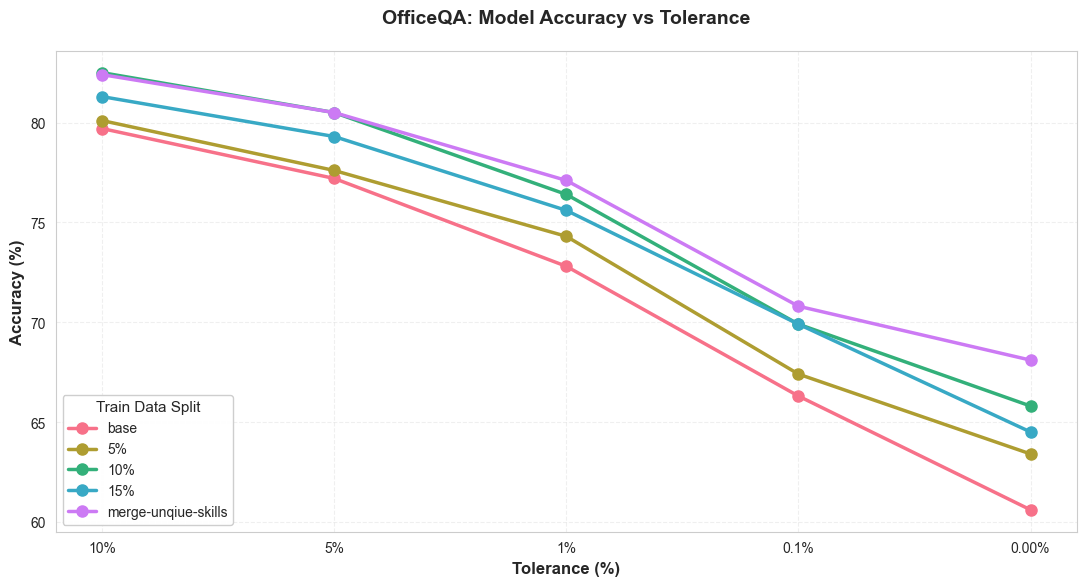

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set style for professional look
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (11, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['figure.dpi'] = 100

# Extract tolerance values from column names
tolerance_cols = df.columns.tolist()
tolerances = [float(col.replace('% tol.', '').strip()) for col in tolerance_cols]

# Create evenly spaced x positions (not to scale) for better visibility
x_positions = np.arange(len(tolerances))

# Create the plot with more space for legend
fig, ax = plt.subplots(figsize=(11, 6))

# Define a professional color palette
colors = sns.color_palette("husl", len(df.index))

# Plot each train data split as a line
for idx, (split_name, row) in enumerate(df.iterrows()):
    ax.plot(x_positions, row.values, marker='o', linewidth=2.5, 
            markersize=8, label=split_name, color=colors[idx])

# Customize the plot
ax.set_xlabel('Tolerance (%)', fontweight='bold')
ax.set_ylabel('Accuracy (%)', fontweight='bold')
ax.set_title('OfficeQA: Model Accuracy vs Tolerance', 
             fontweight='bold', pad=20)
ax.grid(True, alpha=0.3, linestyle='--')

# Move legend to bottom left
ax.legend(title='Train Data Split', title_fontsize=11, 
          loc='lower left', framealpha=0.95)

# Set x-axis to show tolerance values with even spacing
ax.set_xticks(x_positions)
# Format labels: show 0.1% instead of 0.10%, and others appropriately
ax.set_xticklabels([f'{t:.1f}%' if t == 0.1 else (f'{t:.2f}%' if t < 1 else f'{t:.0f}%') for t in tolerances])

# Reverse the x-axis so 0% appears last
ax.invert_xaxis()

# Add padding to prevent legend from overlapping
plt.tight_layout()

# Show the plot
plt.show()